#  Tugas 3 — Ekstraksi Fitur dan Clustering Data Time Series

**Studi kasus:** Polutan udara Kecamatan Klampis, Kabupaten Bangkalan



# 1. Persiapan


In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tsfel
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.display import display, Markdown

BASE_DIR = Path.cwd()
print(f"Folder kerja: {BASE_DIR}")
print("Library siap")

Folder kerja: c:\Users\SIRUL AMIN\Documents\psd_b_1
Library siap


In [2]:
excel_candidates = sorted(BASE_DIR.glob("*.xlsx")) + sorted(BASE_DIR.glob("*.xls"))
if not excel_candidates:
    raise FileNotFoundError("Tidak ditemukan file Excel TSFEL (*.xlsx/*.xls) di folder kerja.")
excel_path = excel_candidates[0]
xls = pd.ExcelFile(excel_path)
print("File:", excel_path.name)
print("Sheet:", xls.sheet_names)

File: data_tsfel_20260920_080900.xlsx
Sheet: ['Semua Fitur', 'CO', 'SO2', 'CH4', 'NO2']


# 2. Time Series setiap Polutan

Upload CSV hasil crawling untuk CO, SO₂, CH₄, dan NO₂. Notebook mendeteksi kolom tanggal dan kolom nilai secara otomatis.


In [3]:
def detect_date(df):
    candidates = [x for x in df.columns if any(k in str(x).lower() for k in ['date', 'tanggal', 'time', 'datetime'])]
    return candidates[0] if candidates else None

def detect_value(df, pollutant):
    pollutant = pollutant.lower()
    preferred = [x for x in df.columns if pollutant in str(x).lower() and any(k in str(x).lower() for k in ['mean', 'value', 'data'])]
    if preferred:
        return preferred[0]
    numeric = df.select_dtypes(include=np.number).columns.tolist()
    return numeric[0] if numeric else None

def load_ts(file_path, pollutant):
    data = pd.read_csv(file_path)
    date_col = detect_date(data)
    value_col = detect_value(data, pollutant)
    if date_col is None or value_col is None:
        return None
    result = data[[date_col, value_col]].copy()
    result.columns = ['tanggal', pollutant]
    result['tanggal'] = pd.to_datetime(result['tanggal'], errors='coerce')
    result[pollutant] = pd.to_numeric(result[pollutant], errors='coerce')
    return result.dropna(subset=['tanggal', pollutant]).sort_values('tanggal').reset_index(drop=True)

csv_files = sorted(BASE_DIR.glob('*.csv'))
time_series = {}
for pollutant in ['CO', 'SO2', 'CH4', 'NO2']:
    matches = [f for f in csv_files if pollutant.lower() in f.name.lower() and 'custom' not in f.name.lower()]
    if matches:
        loaded = load_ts(matches[0], pollutant)
        if loaded is not None and not loaded.empty:
            time_series[pollutant] = loaded
            print(f"{pollutant}: {matches[0].name} -> {loaded.shape}")

if not time_series:
    raise FileNotFoundError("Tidak ada CSV polutan yang berhasil dibaca.")
print('Berhasil:', list(time_series))

CO: CO_365_hari_preprocessed.csv -> (365, 2)
SO2: Sentinel-5P_SO2-SO2_VISUALIZED-2026-02-10T00_00_00_000Z-2026-08-10T23_59_59_999Z.csv -> (125, 2)
CH4: Sentinel-5P_CH4-CH4_VISUALIZED-2025-08-31T00_00_00_000Z-2026-08-31T23_59_59_999Z.csv -> (14, 2)
NO2: Sentinel-5P_NO2-NO2_VISUALIZED-2025-01-28T00_00_00_000Z-2026-01-28T23_59_59_999Z.csv -> (176, 2)
Berhasil: ['CO', 'SO2', 'CH4', 'NO2']


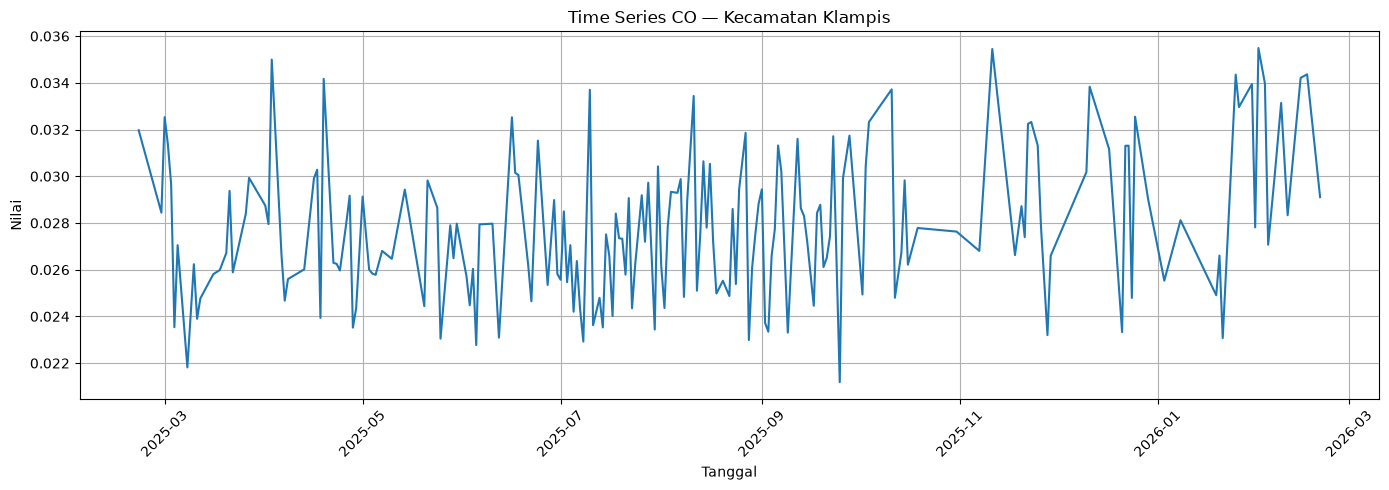

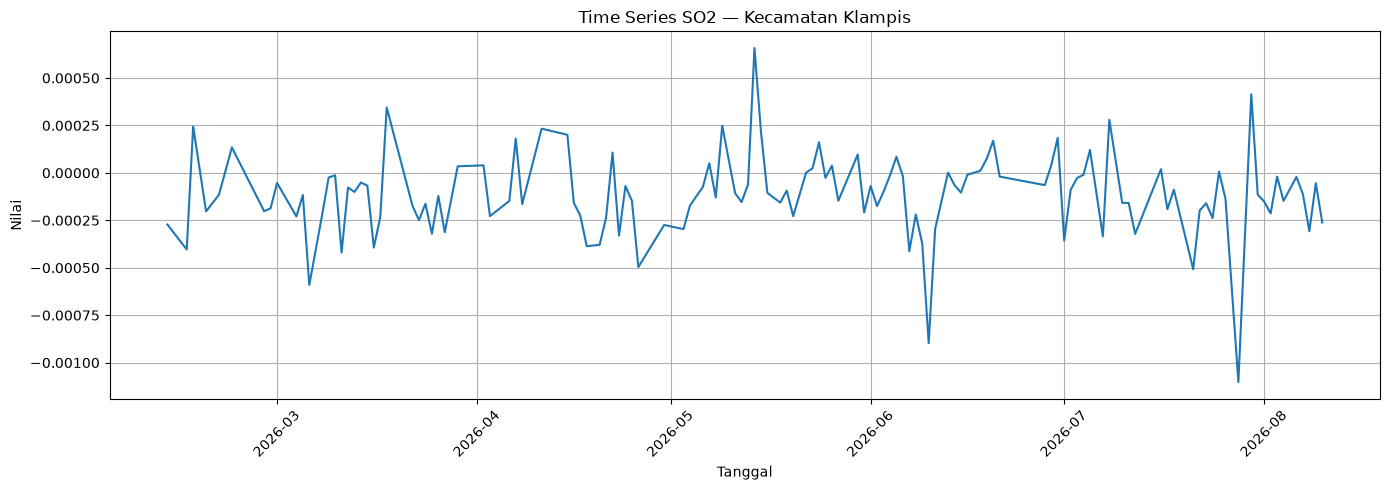

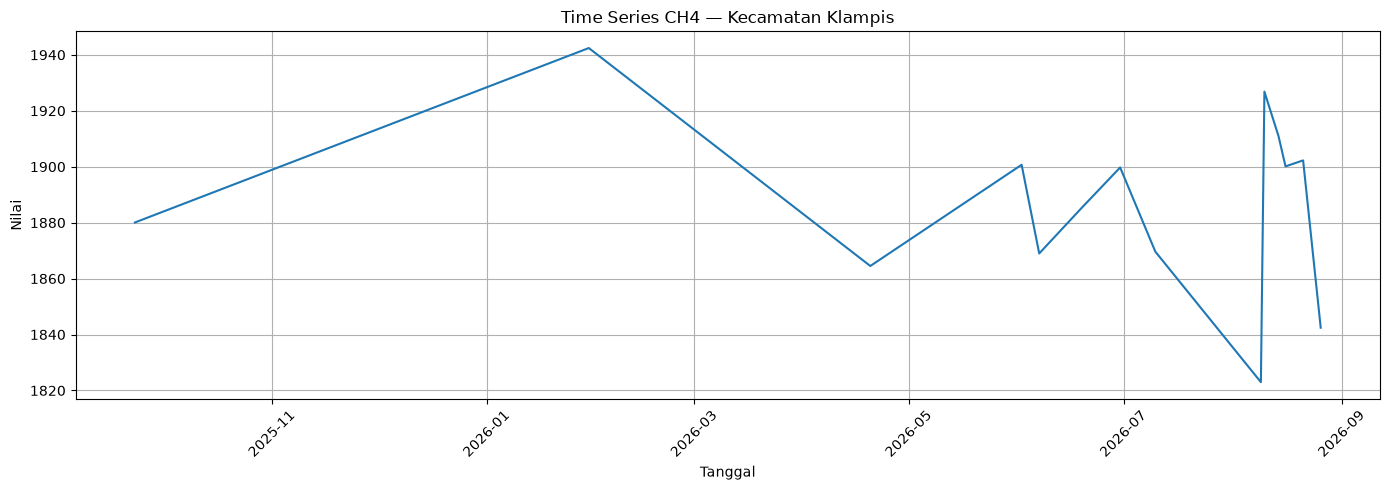

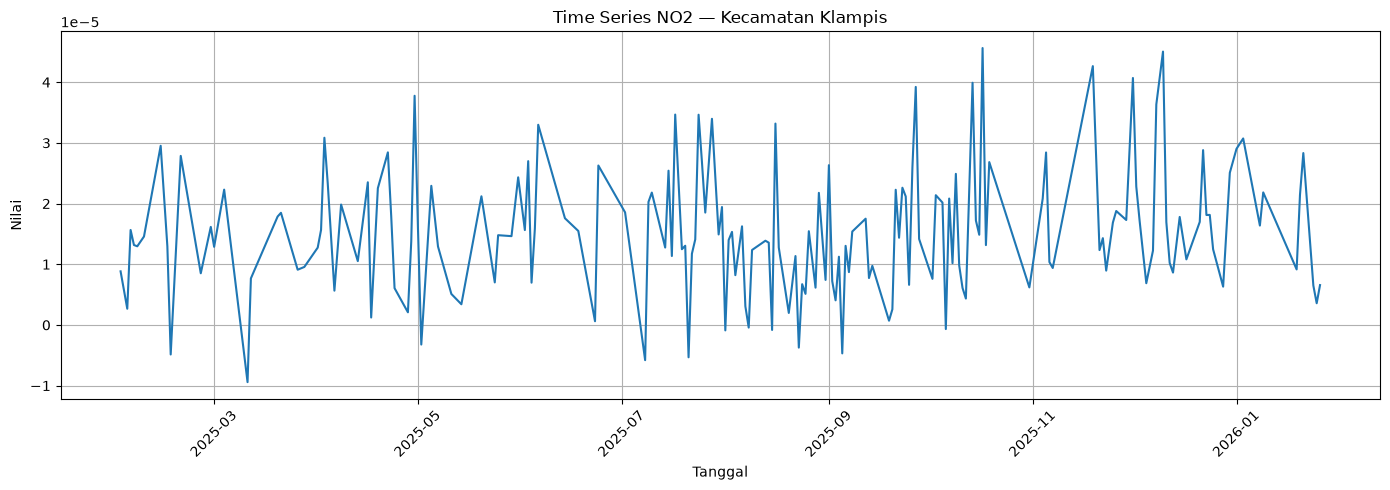

In [4]:
for p,d in time_series.items():
    plt.figure(figsize=(14,5)); plt.plot(d['tanggal'],d[p]); plt.title(f'Time Series {p} — Kecamatan Klampis'); plt.xlabel('Tanggal'); plt.ylabel('Nilai'); plt.xticks(rotation=45); plt.grid(True); plt.tight_layout(); plt.show()


# 3. Statistik Dasar

**Mean** = Σx/n. **Median** = nilai tengah. **Range** = max−min. **Variance** = Σ(x−mean)²/(n−1). **Standard deviation** = √variance. **IQR** = Q3−Q1. Statistik digunakan untuk meringkas pusat, penyebaran, dan rentang data.


In [5]:
for p,d in time_series.items():
    x=d[p].dropna()
    s=pd.Series({'Mean':x.mean(),'Median':x.median(),'Minimum':x.min(),'Maximum':x.max(),'Range':x.max()-x.min(),'Variance':x.var(),'Standard Deviation':x.std(),'Q1':x.quantile(.25),'Q3':x.quantile(.75),'IQR':x.quantile(.75)-x.quantile(.25)})
    print('\n',p); display(s.to_frame('Nilai'))



 CO


,Nilai
Mean,0.028136
Median,0.027740
Minimum,0.021186
Maximum,0.035489
Range,0.014303
Variance,0.000008
Standard Deviation,0.002829
Q1,0.026111
Q3,0.029878
IQR,0.003767



 SO2


,Nilai
Mean,-1.164913e-04
Median,-1.150246e-04
Minimum,-1.102721e-03
Maximum,6.578993e-04
Range,1.760620e-03
Variance,4.957743e-08
Standard Deviation,2.226599e-04
Q1,-2.247811e-04
Q3,-9.789785e-06
IQR,2.149913e-04



 CH4


,Nilai
Mean,1886.915187
Median,1892.460144
Minimum,1822.977173
Maximum,1942.427246
Range,119.450073
Variance,1019.635902
Standard Deviation,31.931738
Q1,1869.147491
Q3,1901.871063
IQR,32.723572



 NO2


,Nilai
Mean,1.527128e-05
Median,1.433597e-05
Minimum,-9.422401e-06
Maximum,4.562547e-05
Range,5.504788e-05
Variance,1.100782e-10
Standard Deviation,1.049181e-05
Q1,8.085945e-06
Q3,2.139095e-05
IQR,1.330500e-05


## Contoh manual statistik

Gunakan X = [2, 4, 4, 6, 9]. Mean = (2+4+4+6+9)/5 = 5. Range = 9−2 = 7. Variance sampel = ((2−5)²+(4−5)²+(4−5)²+(6−5)²+(9−5)²)/4 = 7. Standard deviation = √7 ≈ 2.646.


In [6]:
X=np.array([2,4,4,6,9],float)
print(pd.Series({'Mean':X.mean(),'Median':np.median(X),'Range':X.max()-X.min(),'Variance sample':X.var(ddof=1),'Std sample':X.std(ddof=1),'Q1':np.quantile(X,.25),'Q3':np.quantile(X,.75),'IQR':np.quantile(X,.75)-np.quantile(X,.25)}))


Mean               5.000000
Median             4.000000
Range              7.000000
Variance sample    7.000000
Std sample         2.645751
Q1                 4.000000
Q3                 6.000000
IQR                2.000000
dtype: float64


# 4. 68 Fitur TSFEL

Daftar berikut mengikuti urutan 68 kelompok fitur yang digunakan pada notebook sebelumnya. Untuk fitur yang menghasilkan beberapa koefisien (misalnya MFCC/LPCC/ECDF/wavelet), kelompok fitur tetap diperlakukan sebagai satu kelompok sesuai format tugas.


|No|Fitur|Konsep/bentuk perhitungan|
|---:|---|---|
|1|**Absolute energy**|`Σx²`|
|2|**Area under the curve**|`luas numerik di bawah kurva`|
|3|**Autocorrelation**|`Σx[t]x[t−lag]`|
|4|**Average power**|`Σx²/n`|
|5|**Centroid**|`Σ(i·xᵢ)/Σxᵢ`|
|6|**Max**|`max(x)`|
|7|**Mean**|`Σx/n`|
|8|**Median**|`median(x)`|
|9|**Min**|`min(x)`|
|10|**Standard deviation**|`√variance`|
|11|**Variance**|`Σ(x−mean)²/(n−1)`|
|12|**DFA**|`estimasi detrended fluctuation analysis`|
|13|**Signal distance**|`jumlah jarak antar titik`|
|14|**ECDF**|`F(x)=count(xᵢ≤x)/n`|
|15|**ECDF Percentile**|`quantile(x,p)`|
|16|**ECDF Percentile Count**|`count pada ambang persentil`|
|17|**ECDF Slope**|`ΔECDF/Δx`|
|18|**Entropy**|`−Σp log₂p`|
|19|**Fundamental frequency**|`frekuensi dasar dominan`|
|20|**Higuchi fractal dimension**|`estimasi dimensi fraktal Higuchi`|
|21|**Histogram mode**|`kelas histogram dengan frekuensi terbanyak`|
|22|**Human range energy**|`energi pada rentang frekuensi suara manusia`|
|23|**Hurst exponent**|`estimasi persistence/anti-persistence`|
|24|**Interquartile range**|`Q3−Q1`|
|25|**Kurtosis**|`momen ke-4 terstandar`|
|26|**Lempel-Ziv**|`jumlah pola baru dalam urutan`|
|27|**LPCC**|`koefisien cepstral berbasis linear prediction`|
|28|**Maximum frequency**|`max(f)`|
|29|**Max power spectrum**|`max(P(f))`|
|30|**Maximum fractal length**|`panjang fraktal maksimum`|
|31|**Mean absolute deviation**|`Σ|x−mean|/n`|
|32|**Mean absolute diff**|`Σ|xᵢ−xᵢ₋₁|/(n−1)`|
|33|**Mean diff**|`Σ(xᵢ−xᵢ₋₁)/(n−1)`|
|34|**Median absolute deviation**|`median(|x−median(x)|)`|
|35|**Median absolute diff**|`median(|xᵢ−xᵢ₋₁|)`|
|36|**Median diff**|`median(xᵢ−xᵢ₋₁)`|
|37|**Median frequency**|`frekuensi saat kumulatif energi = 50%`|
|38|**MFCC**|`koefisien cepstral pada skala Mel`|
|39|**MSE**|`Σ(y−ŷ)²/n`|
|40|**Negative turning points**|`jumlah titik belok lokal negatif`|
|41|**Neighbourhood peaks**|`jumlah puncak lokal`|
|42|**Petrosian fractal dimension**|`estimasi kompleksitas/fraktal`|
|43|**Peak to peak distance**|`max(x)−min(x)`|
|44|**Positive turning points**|`jumlah titik belok lokal positif`|
|45|**Power bandwidth**|`f_high−f_low`|
|46|**Root mean square**|`√(Σx²/n)`|
|47|**Skewness**|`momen ke-3 terstandar`|
|48|**Slope**|`Δy/Δx / regresi linear`|
|49|**Spectral centroid**|`Σ(fA)/ΣA`|
|50|**Spectral decrease**|`laju penurunan energi spektrum`|
|51|**Spectral distance**|`jarak distribusi spektral`|
|52|**Spectral entropy**|`−Σp(f)log₂p(f)`|
|53|**Spectral kurtosis**|`kurtosis distribusi energi spektrum`|
|54|**Spectral positive turning**|`titik belok positif spektral`|
|55|**Spectral roll-off**|`frekuensi saat energi kumulatif mencapai threshold`|
|56|**Spectral roll-on**|`frekuensi awal threshold energi`|
|57|**Spectral skewness**|`skewness spektrum`|
|58|**Spectral slope**|`slope regresi spektrum`|
|59|**Spectral spread**|`√(ΣA(f−SC)²/ΣA)`|
|60|**Spectral variation**|`perubahan bentuk spektrum`|
|61|**Spectrogram mean coefficient**|`mean koefisien spectrogram`|
|62|**Sum absolute diff**|`Σ|xᵢ−xᵢ₋₁|`|
|63|**Wavelet absolute mean**|`mean(|W|)`|
|64|**Wavelet energy**|`ΣW²`|
|65|**Wavelet entropy**|`−Σp(W)log₂p(W)`|
|66|**Wavelet standard deviation**|`std(W)`|
|67|**Wavelet variance**|`var(W)`|
|68|**Zero crossing rate**|`jumlah perubahan tanda`|


## Contoh manual + verifikasi TSFEL

Untuk X=[2,−1,3,−2,4]: RMS = √((4+1+9+4+16)/5)=√6.8≈2.608. Zero crossing = 4 karena semua pasangan berubah tanda. Mean absolute difference = (3+4+5+6)/4 = 4.5. Fitur sederhana diverifikasi dengan TSFEL berikut.


In [8]:
X = np.array([2, -1, 3, -2, 4], dtype=float)
cfg = tsfel.get_features_by_domain('temporal')
r = tsfel.time_series_features_extractor(cfg, X, verbose=0)

rms_columns = [c for c in r.columns if 'root mean square' in c.lower() or 'rms' in c.lower()]
diff_columns = [c for c in r.columns if 'mean absolute diff' in c.lower()]

print('Manual RMS:', np.sqrt(np.mean(X ** 2)))
print('Manual Mean absolute diff:', np.mean(np.abs(np.diff(X))))
print('Manual Zero crossing:', np.sum(np.sign(X[:-1]) != np.sign(X[1:])))
print('TSFEL Root mean square columns:')
display(r[rms_columns])
print('TSFEL Mean absolute diff columns:')
display(r[diff_columns])

Manual RMS: 2.6076809620810595
Manual Mean absolute diff: 4.5
Manual Zero crossing: 4
TSFEL Root mean square columns:


C:\Users\SIRUL AMIN\AppData\Local\Temp\ipykernel_3408\3140777969.py:3: UserWarning: Using default sampling frequency set in configuration file.
  r = tsfel.time_series_features_extractor(cfg, X, verbose=0)


""
0


TSFEL Mean absolute diff columns:


,0_Mean absolute diff
0,4.5


> Untuk fitur kompleks seperti DFA, Higuchi, Lempel-Ziv, LPCC, MFCC, wavelet, dan fitur spektral, perhitungan manual penuh terdiri dari beberapa tahap algoritmik. Tabel di atas memberi konsep dan bentuk perhitungannya; nilai aktual diverifikasi oleh implementasi TSFEL.


# 5. Menyiapkan 68 Fitur per Polutan


In [9]:
sheet_map={}
for p in ['CO','SO2','CH4','NO2']:
    if p in xls.sheet_names:
        sheet_map[p]=pd.read_excel(excel_path,sheet_name=p)
        print(p,sheet_map[p].shape)

def numeric_features(df):
    ids=[c for c in df.columns if str(c).lower() in ['nama','daerah','name','region','rowid']]
    X=df.drop(columns=ids,errors='ignore').apply(pd.to_numeric,errors='coerce')
    X=X.dropna(axis=1,how='all').fillna(X.median(numeric_only=True)).dropna(axis=1,how='all')
    return X.iloc[:,:68].copy()

X_polutan={p:numeric_features(d) for p,d in sheet_map.items()}
for p,X in X_polutan.items(): print(p,X.shape)


CO (19, 70)
SO2 (19, 70)
CH4 (19, 70)
NO2 (19, 70)
CO (19, 68)
SO2 (19, 68)
CH4 (19, 68)
NO2 (19, 68)


# 6. Standardisasi dan PCA

Standardisasi menggunakan z-score: z=(x−μ)/σ. PCA digunakan setelah standardisasi.


In [10]:
X_scaled={}
for p,X in X_polutan.items():
    X_scaled[p]=StandardScaler().fit_transform(X)

def pca_eval(X):
    maxc=min(X.shape[0],X.shape[1])
    p=PCA(n_components=maxc); Z=p.fit_transform(X)
    t=pd.DataFrame({'PCA':range(1,maxc+1),'Explained Variance':p.explained_variance_ratio_,'Cumulative Variance':np.cumsum(p.explained_variance_ratio_)})
    return p,Z,t

pca_results={}
for p,X in X_scaled.items():
    model,Z,t=pca_eval(X); pca_results[p]=(model,Z,t)
    print('\n',p); display(t)



 CO


,PCA,Explained Variance,Cumulative Variance
0,1,2.677525e-01,0.267753
1,2,1.465473e-01,0.414300
2,3,1.425428e-01,0.556843
3,4,1.241031e-01,0.680946
4,5,9.729037e-02,0.778236
5,6,5.303537e-02,0.831272
6,7,4.271927e-02,0.873991
7,8,3.421218e-02,0.908203
8,9,3.031661e-02,0.938520
9,10,2.100400e-02,0.959524



 SO2


,PCA,Explained Variance,Cumulative Variance
0,1,3.956521e-01,0.395652
1,2,1.623380e-01,0.557990
2,3,1.160167e-01,0.674007
3,4,9.469806e-02,0.768705
4,5,8.032881e-02,0.849034
5,6,6.395607e-02,0.912990
6,7,2.617385e-02,0.939164
7,8,1.663626e-02,0.955800
8,9,1.338955e-02,0.969189
9,10,1.192290e-02,0.981112



 CH4


,PCA,Explained Variance,Cumulative Variance
0,1,2.042998e-01,0.204300
1,2,1.806557e-01,0.384955
2,3,1.235707e-01,0.508526
3,4,1.053203e-01,0.613846
4,5,8.767051e-02,0.701517
5,6,8.052077e-02,0.782038
6,7,5.819108e-02,0.840229
7,8,3.877150e-02,0.879000
8,9,3.460211e-02,0.913602
9,10,2.751406e-02,0.941117



 NO2


,PCA,Explained Variance,Cumulative Variance
0,1,5.702286e-01,0.570229
1,2,1.155159e-01,0.685745
2,3,8.994128e-02,0.775686
3,4,7.022529e-02,0.845911
4,5,4.512948e-02,0.891041
5,6,3.856358e-02,0.929604
6,7,2.373726e-02,0.953341
7,8,1.598707e-02,0.969328
8,9,1.058942e-02,0.979918
9,10,5.979031e-03,0.985897


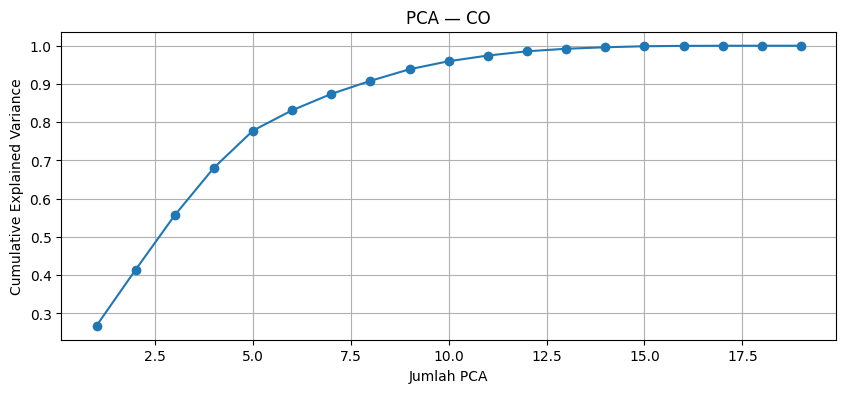

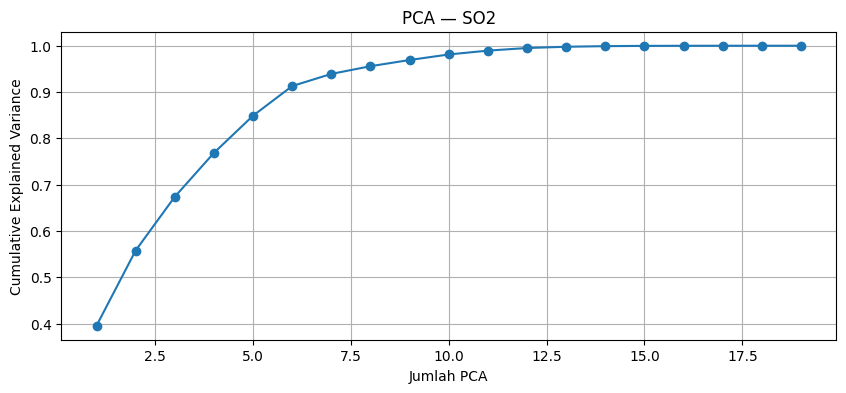

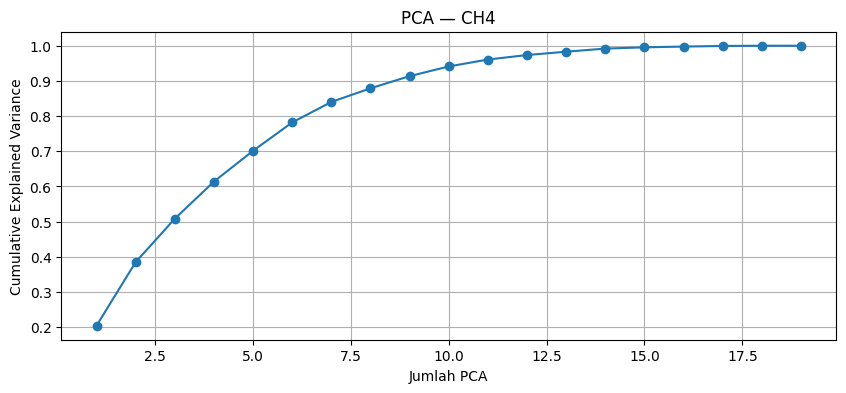

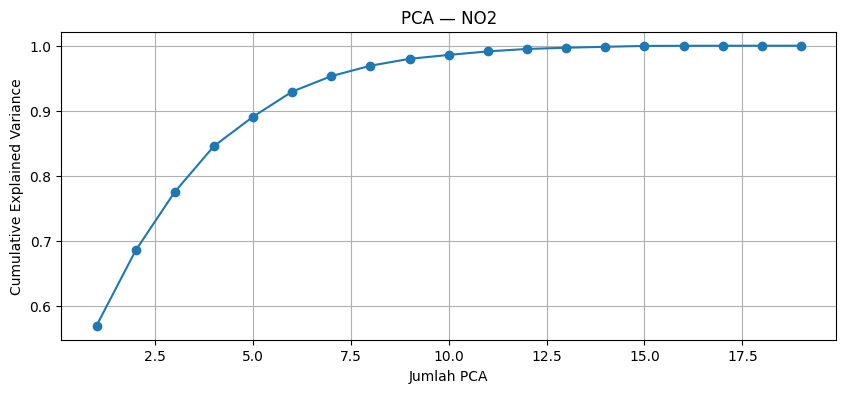

In [10]:
for p,(model,Z,t) in pca_results.items():
    plt.figure(figsize=(10,4)); plt.plot(t.PCA,t['Cumulative Variance'],marker='o'); plt.xlabel('Jumlah PCA'); plt.ylabel('Cumulative Explained Variance'); plt.title(f'PCA — {p}'); plt.grid(True); plt.show()


# 7. Menentukan Jumlah Cluster K-Means

**Elbow** melihat perubahan inertia saat k bertambah. **Silhouette** mengukur kedekatan data dengan cluster sendiri dibandingkan cluster lain. Keduanya dilaporkan bersama; jangan memasukkan label “terbaik” tanpa melihat hasil aktual.



=== CO 68 fitur ===


,k,inertia,silhouette
0,2,964.057223,0.324814
1,3,774.017225,0.344620
2,4,617.527357,0.350798
3,5,437.727750,0.368727
4,6,302.495707,0.303804
5,7,240.516940,0.312133
6,8,196.938399,0.270383


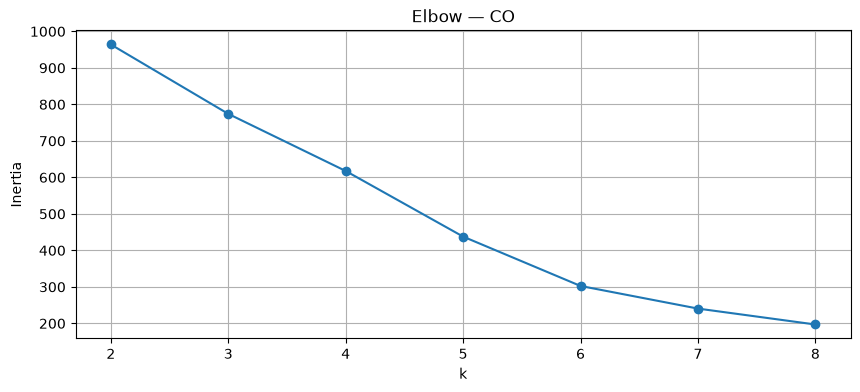

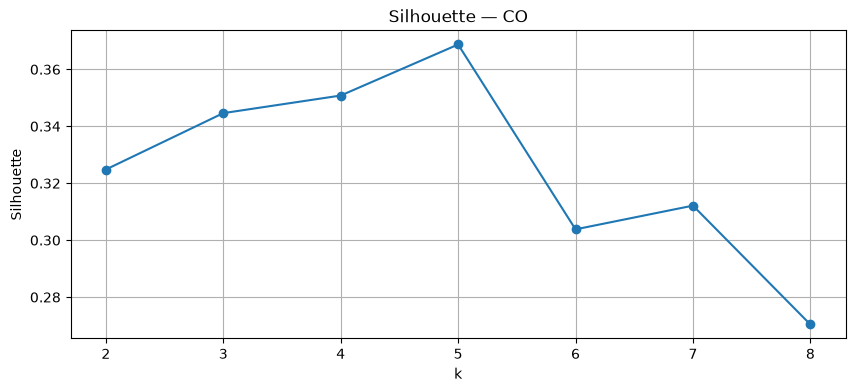


=== SO2 68 fitur ===


,k,inertia,silhouette
0,2,783.945015,0.602519
1,3,613.239490,0.277701
2,4,468.399449,0.302409
3,5,314.368015,0.354668
4,6,210.404856,0.353034
5,7,123.631540,0.381167
6,8,95.986490,0.332544


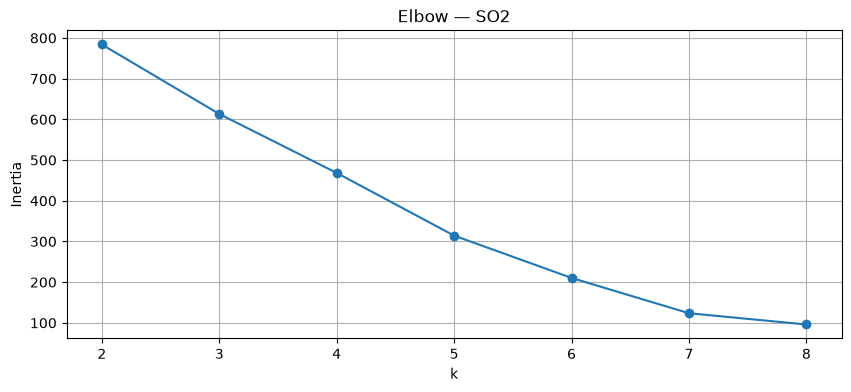

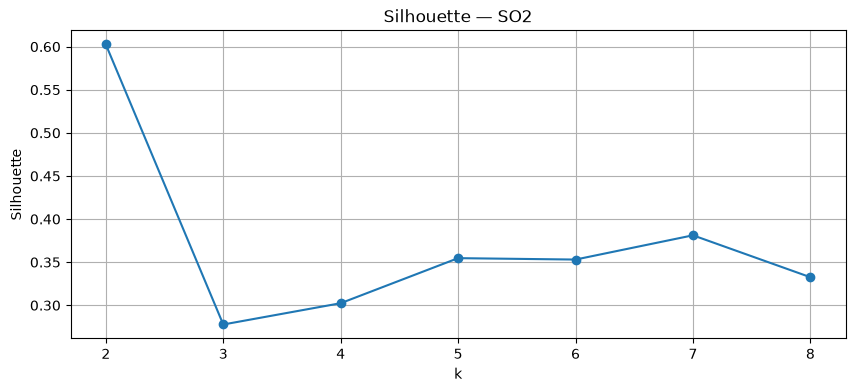


=== CH4 68 fitur ===


,k,inertia,silhouette
0,2,1054.391500,0.182445
1,3,849.085722,0.200287
2,4,689.168945,0.215979
3,5,542.849516,0.263174
4,6,418.448804,0.279260
5,7,311.859519,0.289520
6,8,230.887283,0.286330


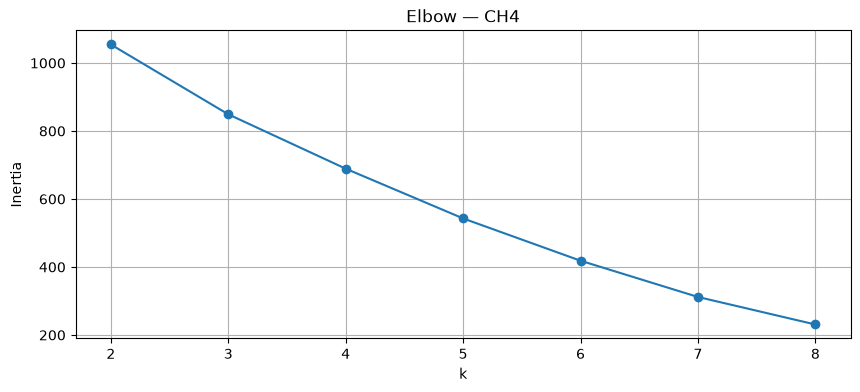

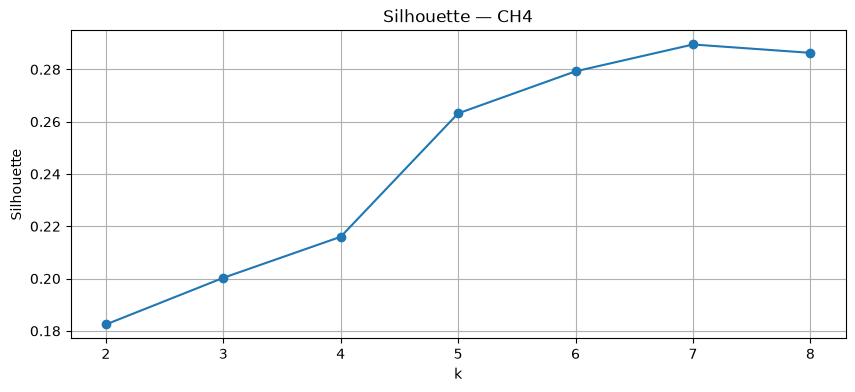


=== NO2 68 fitur ===


,k,inertia,silhouette
0,2,555.822126,0.698217
1,3,413.178326,0.437431
2,4,306.234082,0.264725
3,5,216.865748,0.301787
4,6,163.722722,0.325114
5,7,114.555116,0.342097
6,8,85.183825,0.318740


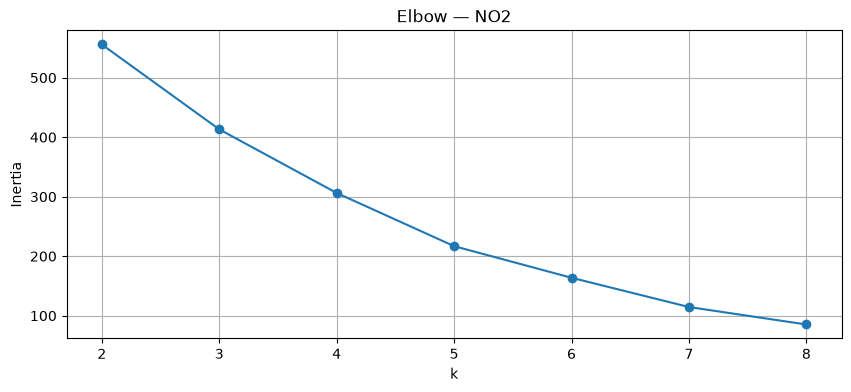

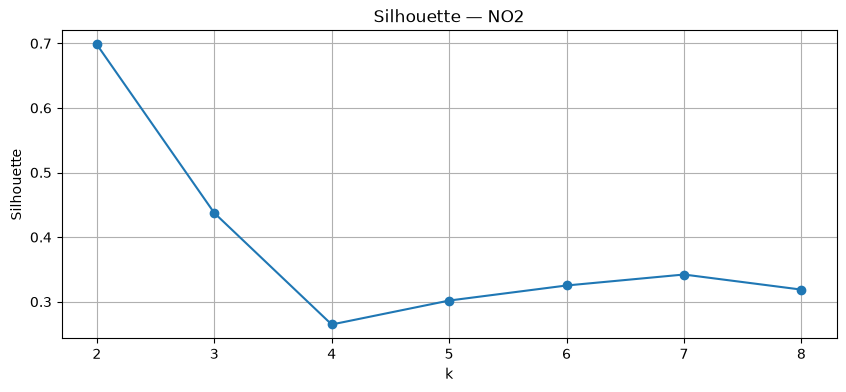

In [11]:
def km_eval(X,kmin=2,kmax=8):
    kmax=min(kmax,X.shape[0]-1); rows=[]
    for k in range(kmin,kmax+1):
        m=KMeans(n_clusters=k,random_state=42,n_init=10); lab=m.fit_predict(X)
        rows.append({'k':k,'inertia':m.inertia_,'silhouette':silhouette_score(X,lab)})
    return pd.DataFrame(rows)

hasil_68={}
for p,X in X_scaled.items():
    e=km_eval(X); hasil_68[p]=e; print('\n===',p,'68 fitur ==='); display(e)
    plt.figure(figsize=(10,4)); plt.plot(e.k,e.inertia,marker='o'); plt.title(f'Elbow — {p}'); plt.xlabel('k'); plt.ylabel('Inertia'); plt.grid(True); plt.show()
    plt.figure(figsize=(10,4)); plt.plot(e.k,e.silhouette,marker='o'); plt.title(f'Silhouette — {p}'); plt.xlabel('k'); plt.ylabel('Silhouette'); plt.grid(True); plt.show()


# 8. PCA 1 sampai PCA yang Feasible + K-Means

Karena hanya ada 19 observasi, notebook menguji PCA 1–18. PCA 19 masih dapat dihitung tetapi evaluasi clustering dengan 19 komponen tidak menambah informasi dibandingkan ruang data penuh; batas PCA tetap dijelaskan secara eksplisit.



 CO


,jumlah_pca,k,silhouette,inertia
0,1,2,0.860115,32.774347
1,1,3,0.744077,12.064243
2,1,4,0.558719,5.053456
3,1,5,0.549227,3.093758
4,1,6,0.514915,1.370478
...,...,...,...,...
121,18,4,0.350798,617.527357
122,18,5,0.368727,437.727750
123,18,6,0.303804,302.495707
124,18,7,0.312133,240.516940


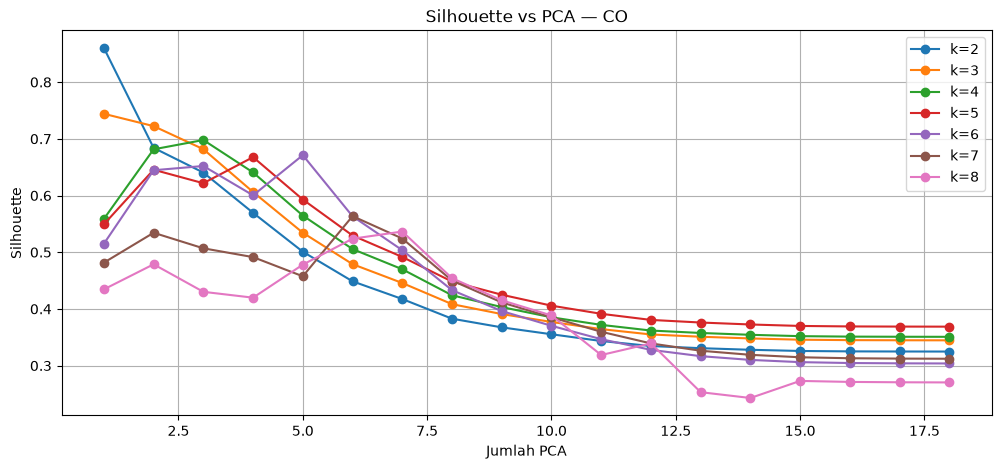


 SO2


,jumlah_pca,k,silhouette,inertia
0,1,2,0.924133,4.935258
1,1,3,0.737865,0.618509
2,1,4,0.699527,0.187749
3,1,5,0.680262,0.088394
4,1,6,0.661316,0.045665
...,...,...,...,...
121,18,4,0.302409,468.399449
122,18,5,0.354668,314.368015
123,18,6,0.353034,210.404856
124,18,7,0.381167,123.631540


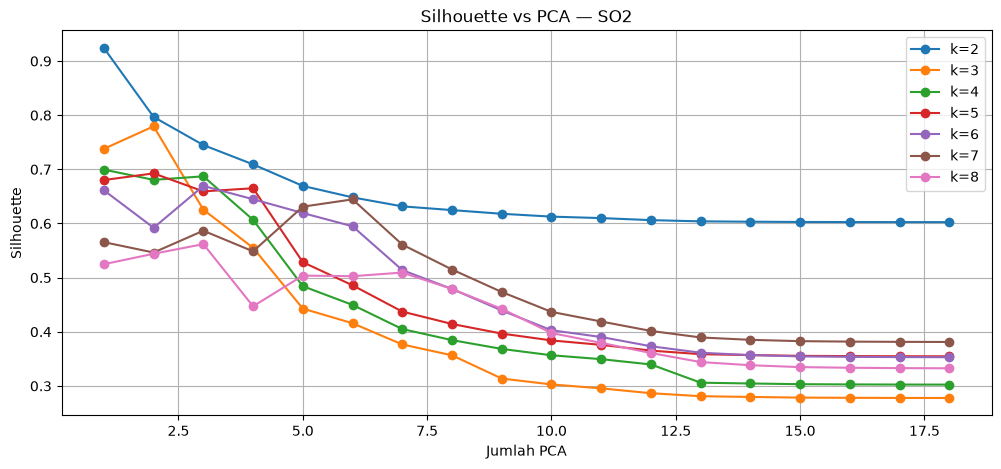


 CH4


,jumlah_pca,k,silhouette,inertia
0,1,2,0.737370,44.372569
1,1,3,0.716637,21.457668
2,1,4,0.689095,8.372903
3,1,5,0.582578,5.269602
4,1,6,0.519443,3.149307
...,...,...,...,...
121,18,4,0.215979,689.168945
122,18,5,0.263174,542.849516
123,18,6,0.279260,418.448804
124,18,7,0.289520,311.859519


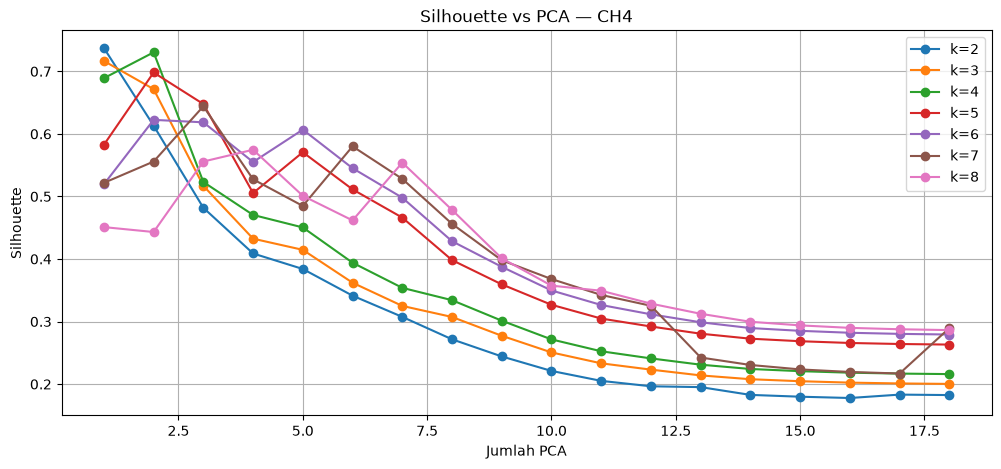


 NO2


,jumlah_pca,k,silhouette,inertia
0,1,2,0.939923,0.618741
1,1,3,0.631925,0.158421
2,1,4,0.608000,0.096789
3,1,5,0.536414,0.036469
4,1,6,0.605417,0.014976
...,...,...,...,...
121,18,4,0.264725,306.234082
122,18,5,0.301787,216.865748
123,18,6,0.325114,163.722722
124,18,7,0.342097,114.555116


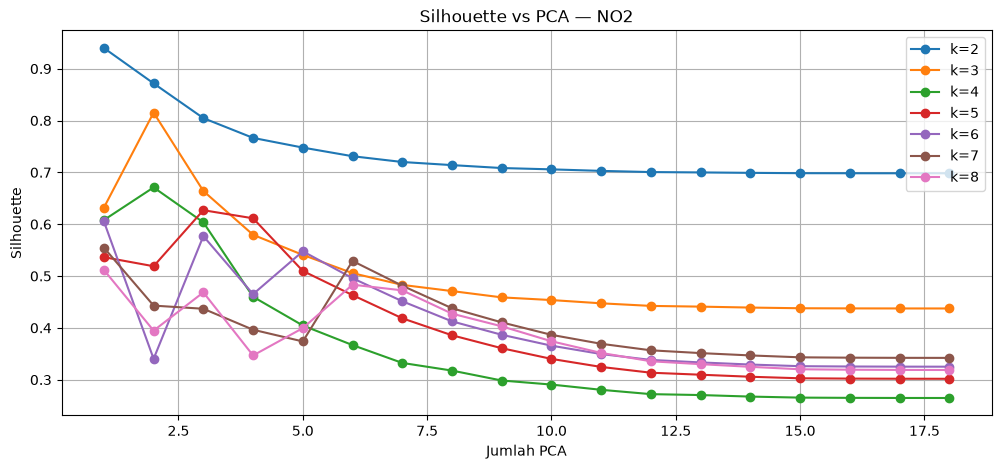

In [12]:
def pca_kmeans_table(X,max_pca=None,kmax=8):
    max_possible=min(X.shape[0],X.shape[1]); max_pca=min(max_possible-1 if max_possible>1 else 1, max_pca or 18)
    rows=[]
    for n in range(1,max_pca+1):
        Z=PCA(n_components=n).fit_transform(X)
        for k in range(2,min(kmax,Z.shape[0]-1)+1):
            m=KMeans(n_clusters=k,random_state=42,n_init=10); lab=m.fit_predict(Z)
            rows.append({'jumlah_pca':n,'k':k,'silhouette':silhouette_score(Z,lab),'inertia':m.inertia_})
    return pd.DataFrame(rows)

pca_cluster={}
for p,X in X_scaled.items():
    t=pca_kmeans_table(X); pca_cluster[p]=t; print('\n',p); display(t)
    piv=t.pivot(index='jumlah_pca',columns='k',values='silhouette')
    plt.figure(figsize=(12,5))
    for k in piv.columns: plt.plot(piv.index,piv[k],marker='o',label=f'k={k}')
    plt.title(f'Silhouette vs PCA — {p}'); plt.xlabel('Jumlah PCA'); plt.ylabel('Silhouette'); plt.grid(True); plt.legend(); plt.show()


# 9. Gabungan 272 Fitur

68 fitur CO + 68 SO₂ + 68 CH₄ + 68 NO₂ = **272 fitur**.


Ukuran: (19, 272)
K-Means 272 fitur


,k,inertia,silhouette
0,2,3801.595148,0.476048
1,3,3006.638507,0.206971
2,4,2475.840746,0.227971
3,5,2042.104440,0.237929
4,6,1662.072535,0.248579
5,7,1279.539413,0.214741
6,8,965.928868,0.222847


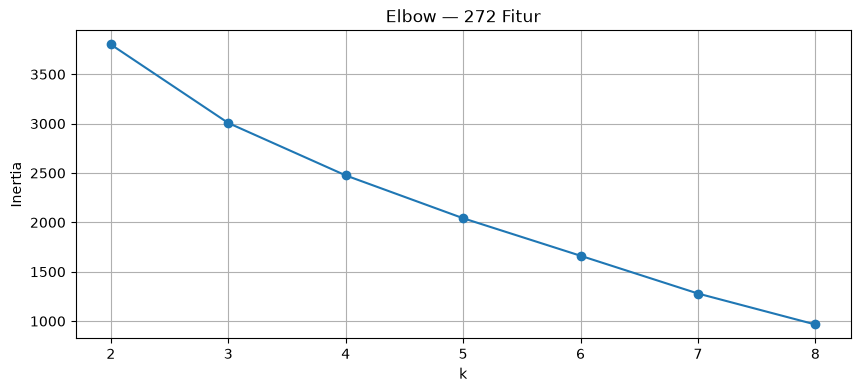

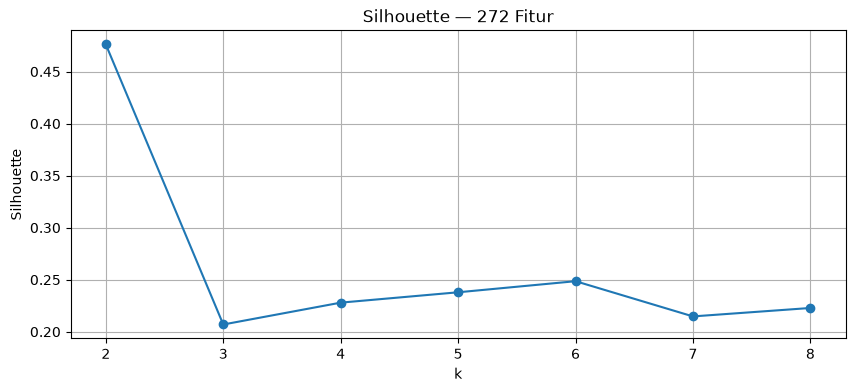

In [13]:
# Gabungkan 68 fitur dari masing-masing polutan
n = min(X.shape[0] for X in X_scaled.values())

X272 = np.hstack([
    X_scaled['CO'][:n],
    X_scaled['SO2'][:n],
    X_scaled['CH4'][:n],
    X_scaled['NO2'][:n]
])

print('Ukuran:', X272.shape)

print('K-Means 272 fitur')

e272 = km_eval(X272)
display(e272)

# Elbow Method
plt.figure(figsize=(10,4))
plt.plot(
    e272.k,
    e272.inertia,
    marker='o'
)
plt.title('Elbow — 272 Fitur')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

# Silhouette Score
plt.figure(figsize=(10,4))
plt.plot(
    e272.k,
    e272.silhouette,
    marker='o'
)
plt.title('Silhouette — 272 Fitur')
plt.xlabel('k')
plt.ylabel('Silhouette')
plt.grid(True)
plt.show()

,PCA,Explained Variance,Cumulative Variance
0,1,2.664122e-01,0.266412
1,2,1.617014e-01,0.428114
2,3,1.150919e-01,0.543205
3,4,8.561558e-02,0.628821
4,5,7.472032e-02,0.703541
5,6,7.203217e-02,0.775574
6,7,5.128498e-02,0.826859
7,8,3.971426e-02,0.866573
8,9,3.370662e-02,0.900279
9,10,2.177191e-02,0.922051


,jumlah_pca,k,silhouette,inertia
0,1,2,0.914868,23.843403
1,1,3,0.728995,3.308835
2,1,4,0.590956,1.748290
3,1,5,0.639319,0.658661
4,1,6,0.594575,0.338721
...,...,...,...,...
121,18,4,0.227971,2475.840746
122,18,5,0.237929,2042.104440
123,18,6,0.248579,1662.072535
124,18,7,0.214741,1279.539413


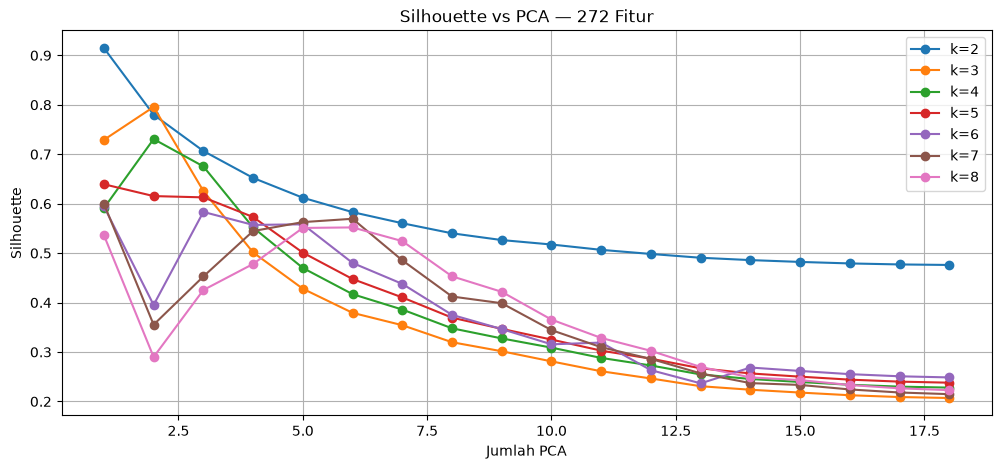

In [14]:
p272,Z272,t272=pca_eval(X272)
display(t272)
t272_small=pca_kmeans_table(X272)
display(t272_small)
piv=t272_small.pivot(index='jumlah_pca',columns='k',values='silhouette')
plt.figure(figsize=(12,5))
for k in piv.columns: plt.plot(piv.index,piv[k],marker='o',label=f'k={k}')
plt.title('Silhouette vs PCA — 272 Fitur'); plt.xlabel('Jumlah PCA'); plt.ylabel('Silhouette'); plt.grid(True); plt.legend(); plt.show()


# 10. Ringkasan

Laporkan: (1) pola time series setiap polutan, (2) statistik dasar, (3) 68 fitur dan contoh perhitungan, (4) verifikasi TSFEL, (5) PCA dan explained variance, (6) Elbow dan Silhouette, (7) hasil 68 fitur tiap polutan, dan (8) hasil 272 fitur.

**Penting:** angka jumlah cluster dan silhouette diisi dari output notebook setelah dijalankan. Jangan mengarang hasil sebelum eksperimen selesai.


In [15]:
ring=[]
for p,e in hasil_68.items():
    r=e.loc[e.silhouette.idxmax()]; ring.append({'Dataset':p+' — 68 fitur','k':int(r.k),'Silhouette':r.silhouette,'Inertia':r.inertia})
r=e272.loc[e272.silhouette.idxmax()]; ring.append({'Dataset':'Gabungan — 272 fitur','k':int(r.k),'Silhouette':r.silhouette,'Inertia':r.inertia})
display(pd.DataFrame(ring))


,Dataset,k,Silhouette,Inertia
0,CO — 68 fitur,5,0.368727,437.727750
1,SO2 — 68 fitur,2,0.602519,783.945015
2,CH4 — 68 fitur,7,0.289520,311.859519
3,NO2 — 68 fitur,2,0.698217,555.822126
4,Gabungan — 272 fitur,2,0.476048,3801.595148
